Keypoint_analisie_for_temporal_normalisation

## Per-File filled palm distance

Directory path: C:\Users\Oscar Strong\Documents\GitHub\BSL-keypoint-processing\Validated_interpolated_SubCorpus_Temporal_Cropping_level1
Directory exists: True

All contents in directory:
  1be98b34-0edc-41ee-871c-e592c0b4198f.json
  3c4d3247-6258-4816-9edf-a0f0e66b20b7.json
  3e9dd7e5-f6a3-4b1f-9f29-9fba66f0b73c.json
  410f85ca-4256-4371-a9b0-17674cdcb9ab.json
  470bf35b-862a-4b90-b359-a8949609792c.json
  601283cf-ba98-48d5-a86c-d0a5ebe61a25.json
  6e5c628d-944c-4a68-8faf-85ffcfaab131.json
  89abb1f9-9daf-48bd-96cd-b0c4afdfa311.json
  8be52121-9cc3-479f-95c3-06baaf2c4dfa.json
  96ec7aed-46c0-4fb3-bdc5-6a0f703ff794.json
  a354b59a-f460-4226-8dc4-24ecdd548230.json
  abf96343-959f-4ff4-9820-50f6c7095e3e.json
  acf7a090-7ece-488a-a6e8-f4df878629a9.json
  bdb61e4d-5010-460d-a721-14b93a8e290f.json
  be885b0b-420b-4796-9db6-a85a215cb563.json
  c179b423-478a-4879-800a-955f385b693e.json
  e7f57b3a-8262-4992-b0b2-f9cf68238935.json
  f21ac459-7925-4a45-ab8d-9067a8667382.json
  ff526205-2756-456f

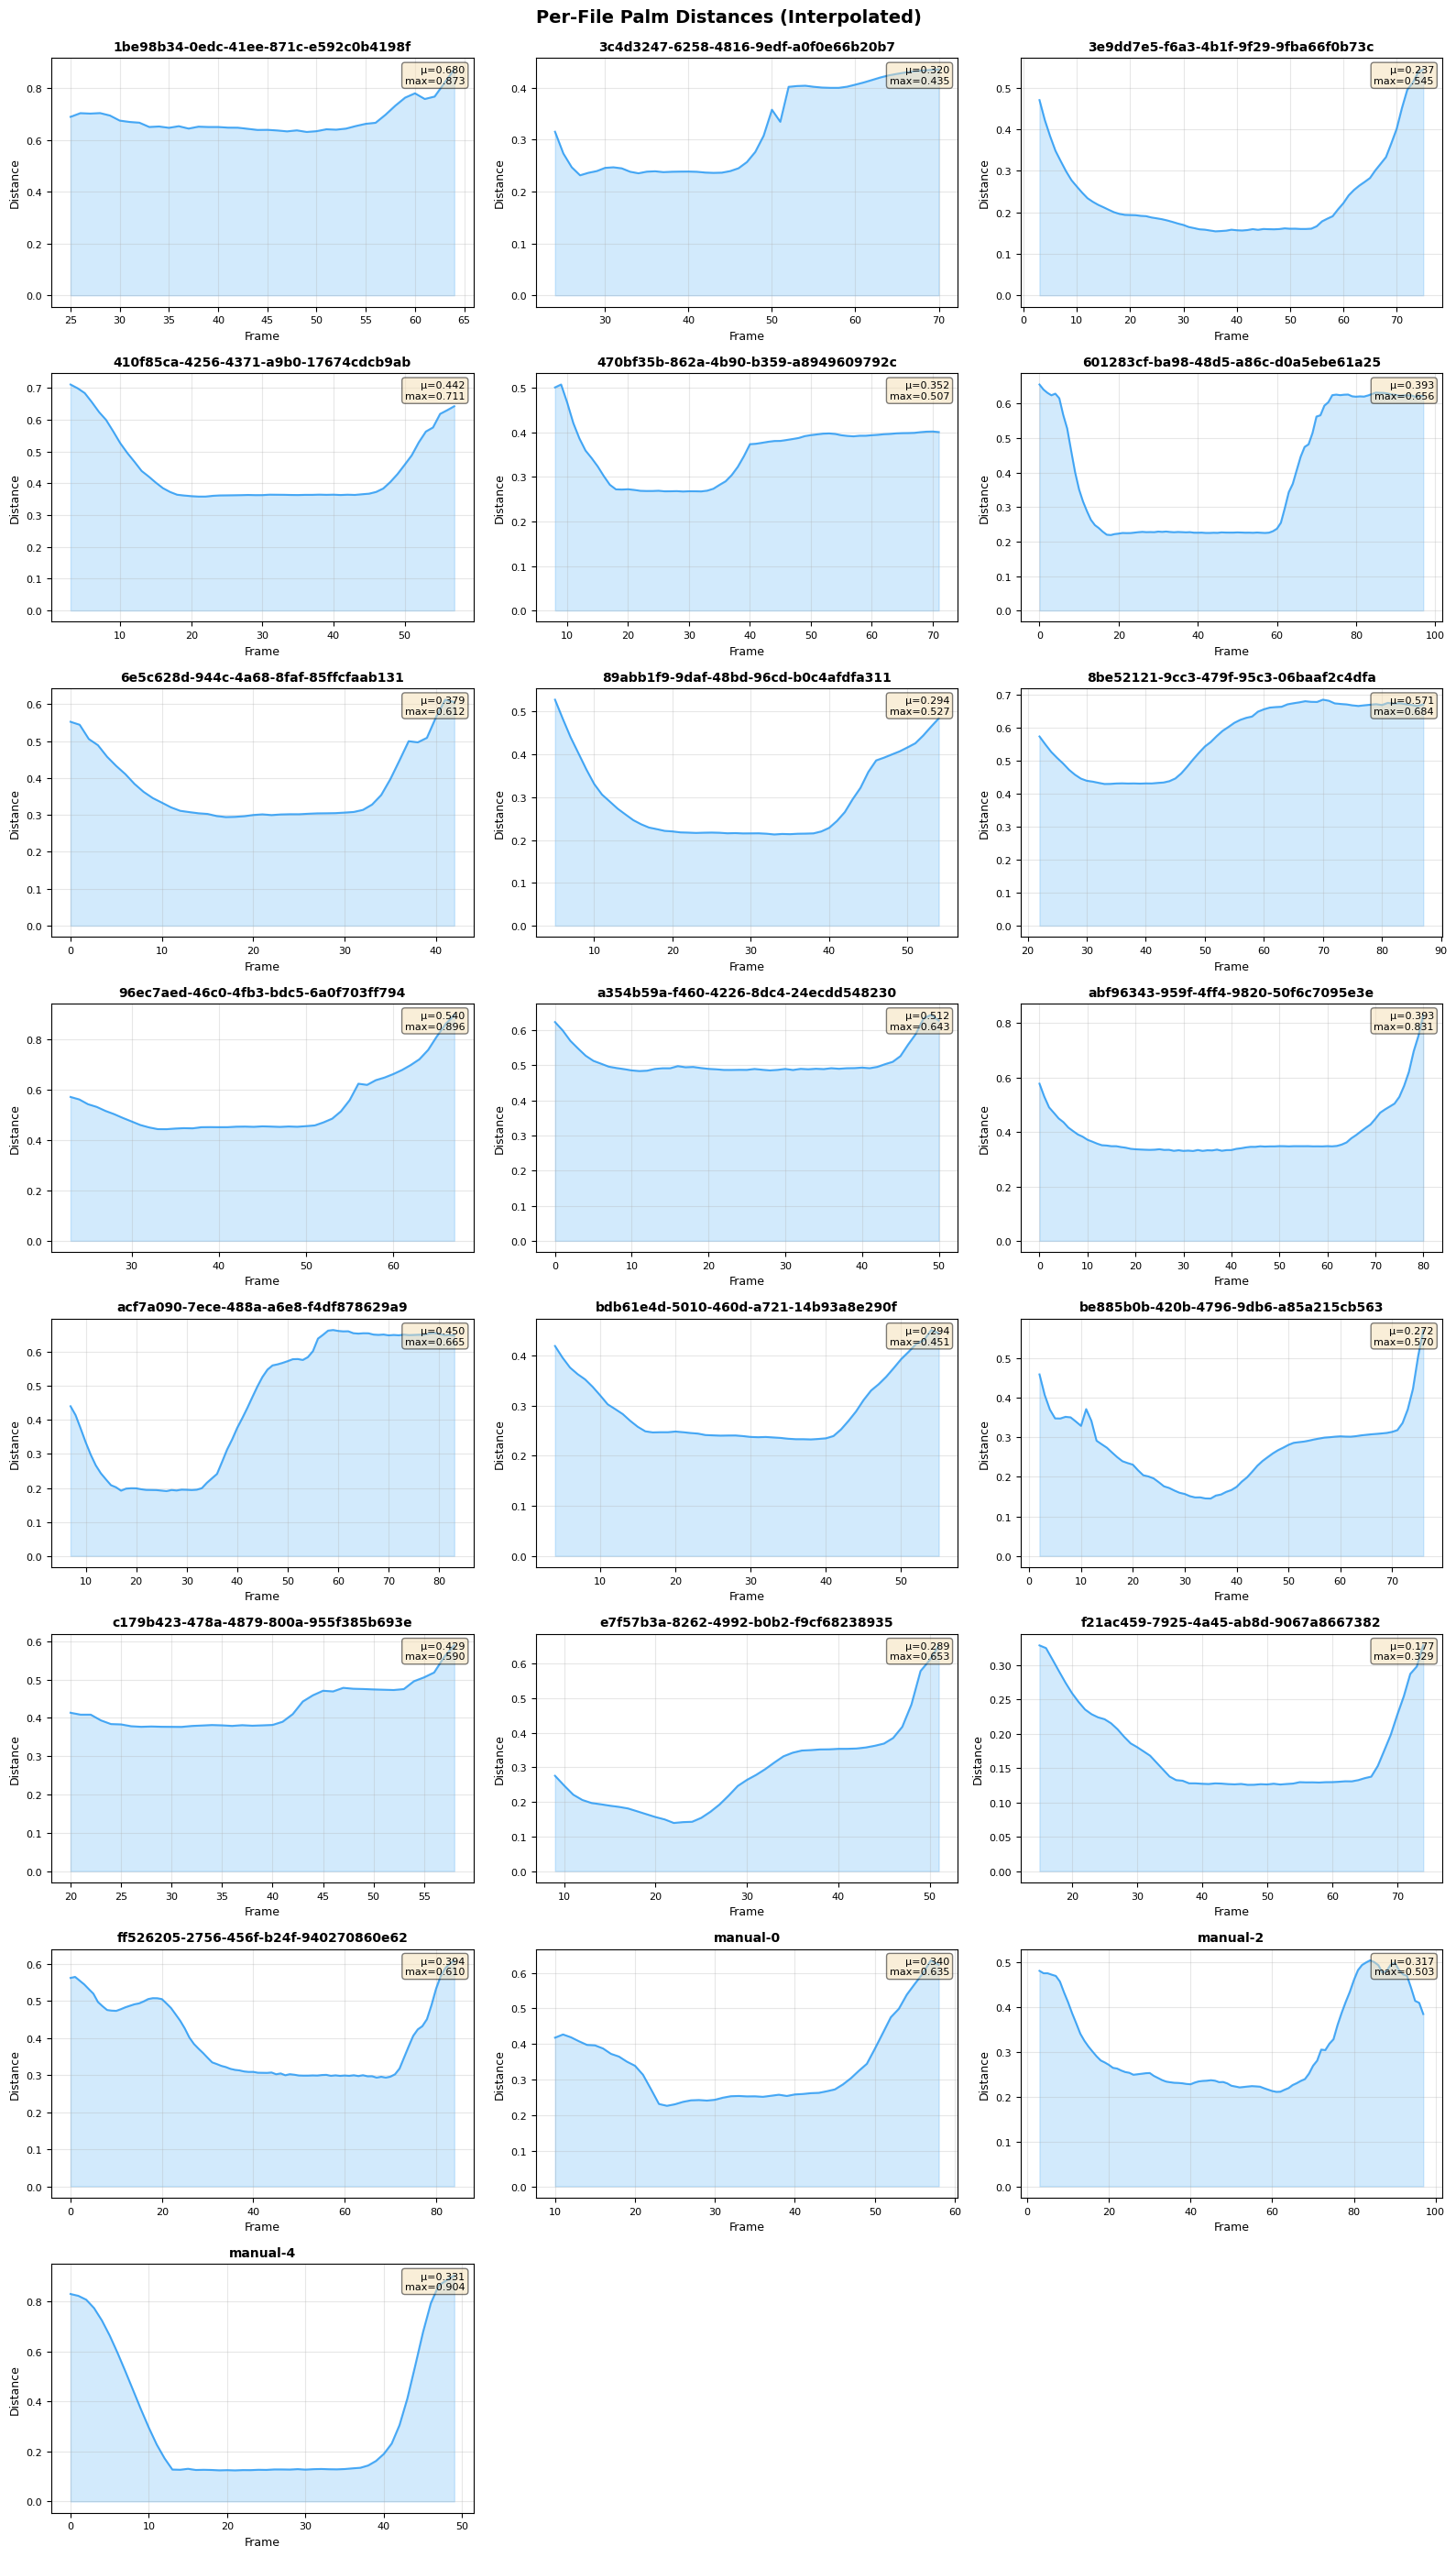


=== Distance Analysis Summary ===
                                file  distance_count  mean_distance  max_distance  min_distance
1be98b34-0edc-41ee-871c-e592c0b4198f              40       0.679898      0.872782      0.631105
3c4d3247-6258-4816-9edf-a0f0e66b20b7              47       0.319556      0.435217      0.231237
3e9dd7e5-f6a3-4b1f-9f29-9fba66f0b73c              73       0.236943      0.544882      0.154470
410f85ca-4256-4371-a9b0-17674cdcb9ab              55       0.442255      0.711242      0.358627
470bf35b-862a-4b90-b359-a8949609792c              64       0.352113      0.507131      0.267119
601283cf-ba98-48d5-a86c-d0a5ebe61a25              98       0.393491      0.655538      0.218977
6e5c628d-944c-4a68-8faf-85ffcfaab131              43       0.379431      0.612292      0.294215
89abb1f9-9daf-48bd-96cd-b0c4afdfa311              50       0.293721      0.527411      0.212962
8be52121-9cc3-479f-95c3-06baaf2c4dfa              66       0.570926      0.683789      0.428794
96ec7

In [ ]:
from Validators.keypoint_validator import CubicSplineKeyPointInterpolator
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import json
import os

# Path to the temporal cropping level directory
corpus_path = Path(r'C:\Users\Oscar Strong\Documents\GitHub\BSL-keypoint-processing\Testing_post_error_ditection_pipeline\Corpus_level_2b')

# Debug: Check if directory exists
print(f"Directory path: {corpus_path}")
print(f"Directory exists: {corpus_path.exists()}")

# List all contents to debug
if corpus_path.exists():
    print(f"\nAll contents in directory:")
    for item in sorted(corpus_path.iterdir()):
        print(f"  {item.name}")

# Get all JSON files
json_files = list(corpus_path.glob('*.json'))
print(f"\nFound {len(json_files)} .json files")

if len(json_files) == 0:
    print("WARNING: No JSON files found! Checking for other patterns...")
    all_files = list(corpus_path.glob('*'))
    print(f"Total items in directory: {len(all_files)}")
else:
    # Create per-file distance plots
    n_files = len(json_files)
    n_cols = 3
    n_rows = int(np.ceil(n_files / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
    fig.suptitle('Per-File Palm Distances (Interpolated)', fontsize=14, fontweight='bold', y=0.995)
    axes_flat = axes.flatten() if n_files > 1 else [axes]

    results_distance = []

    for idx, json_file in enumerate(json_files):
        try:
            # Create interpolator and get distances
            interpolator = CubicSplineKeyPointInterpolator(str(json_file))
            distances = interpolator.findPalmDistances()
            
            file_label = json_file.stem
            results_distance.append({
                'file': file_label,
                'distance_count': len([d for d in distances if d is not None]),
                'mean_distance': np.mean([d for d in distances if d is not None]),
                'max_distance': np.max([d for d in distances if d is not None]),
                'min_distance': np.min([d for d in distances if d is not None]),
            })
            
            # Plot
            ax = axes_flat[idx]
            frame_indices = [i for i, d in enumerate(distances) if d is not None]
            distance_values = [d for d in distances if d is not None]
            
            ax.plot(frame_indices, distance_values, color='#2196F3', linewidth=1.5, alpha=0.8)
            ax.fill_between(frame_indices, distance_values, alpha=0.2, color='#2196F3')
            ax.set_title(f'{file_label}', fontsize=10, fontweight='bold')
            ax.set_xlabel('Frame', fontsize=9)
            ax.set_ylabel('Distance', fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=8)
            
            # Add statistics text
            mean_d = np.mean(distance_values)
            max_d = np.max(distance_values)
            ax.text(0.98, 0.97, f'μ={mean_d:.3f}\nmax={max_d:.3f}', 
                   transform=ax.transAxes, fontsize=8, verticalalignment='top', 
                   horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
        except Exception as e:
            print(f"Error processing {json_file.name}: {e}")
            ax = axes_flat[idx]
            ax.text(0.5, 0.5, f'Error: {str(e)[:30]}', ha='center', va='center', fontsize=9)
            ax.set_title(json_file.stem, fontsize=10, color='red')

    # Hide unused subplots
    for idx in range(n_files, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n=== Distance Analysis Summary ===")
    if results_distance:
        import pandas as pd
        df = pd.DataFrame(results_distance)
        print(df.to_string(index=False))
        print(f"\nCorpus-wide Distance Statistics:")
        print(f"  Mean distance (all files): {df['mean_distance'].mean():.4f}")
        print(f"  Max distance (overall): {df['max_distance'].max():.4f}")
        print(f"  Min distance (overall): {df['min_distance'].min():.4f}")

## Per-File filled palm momentums

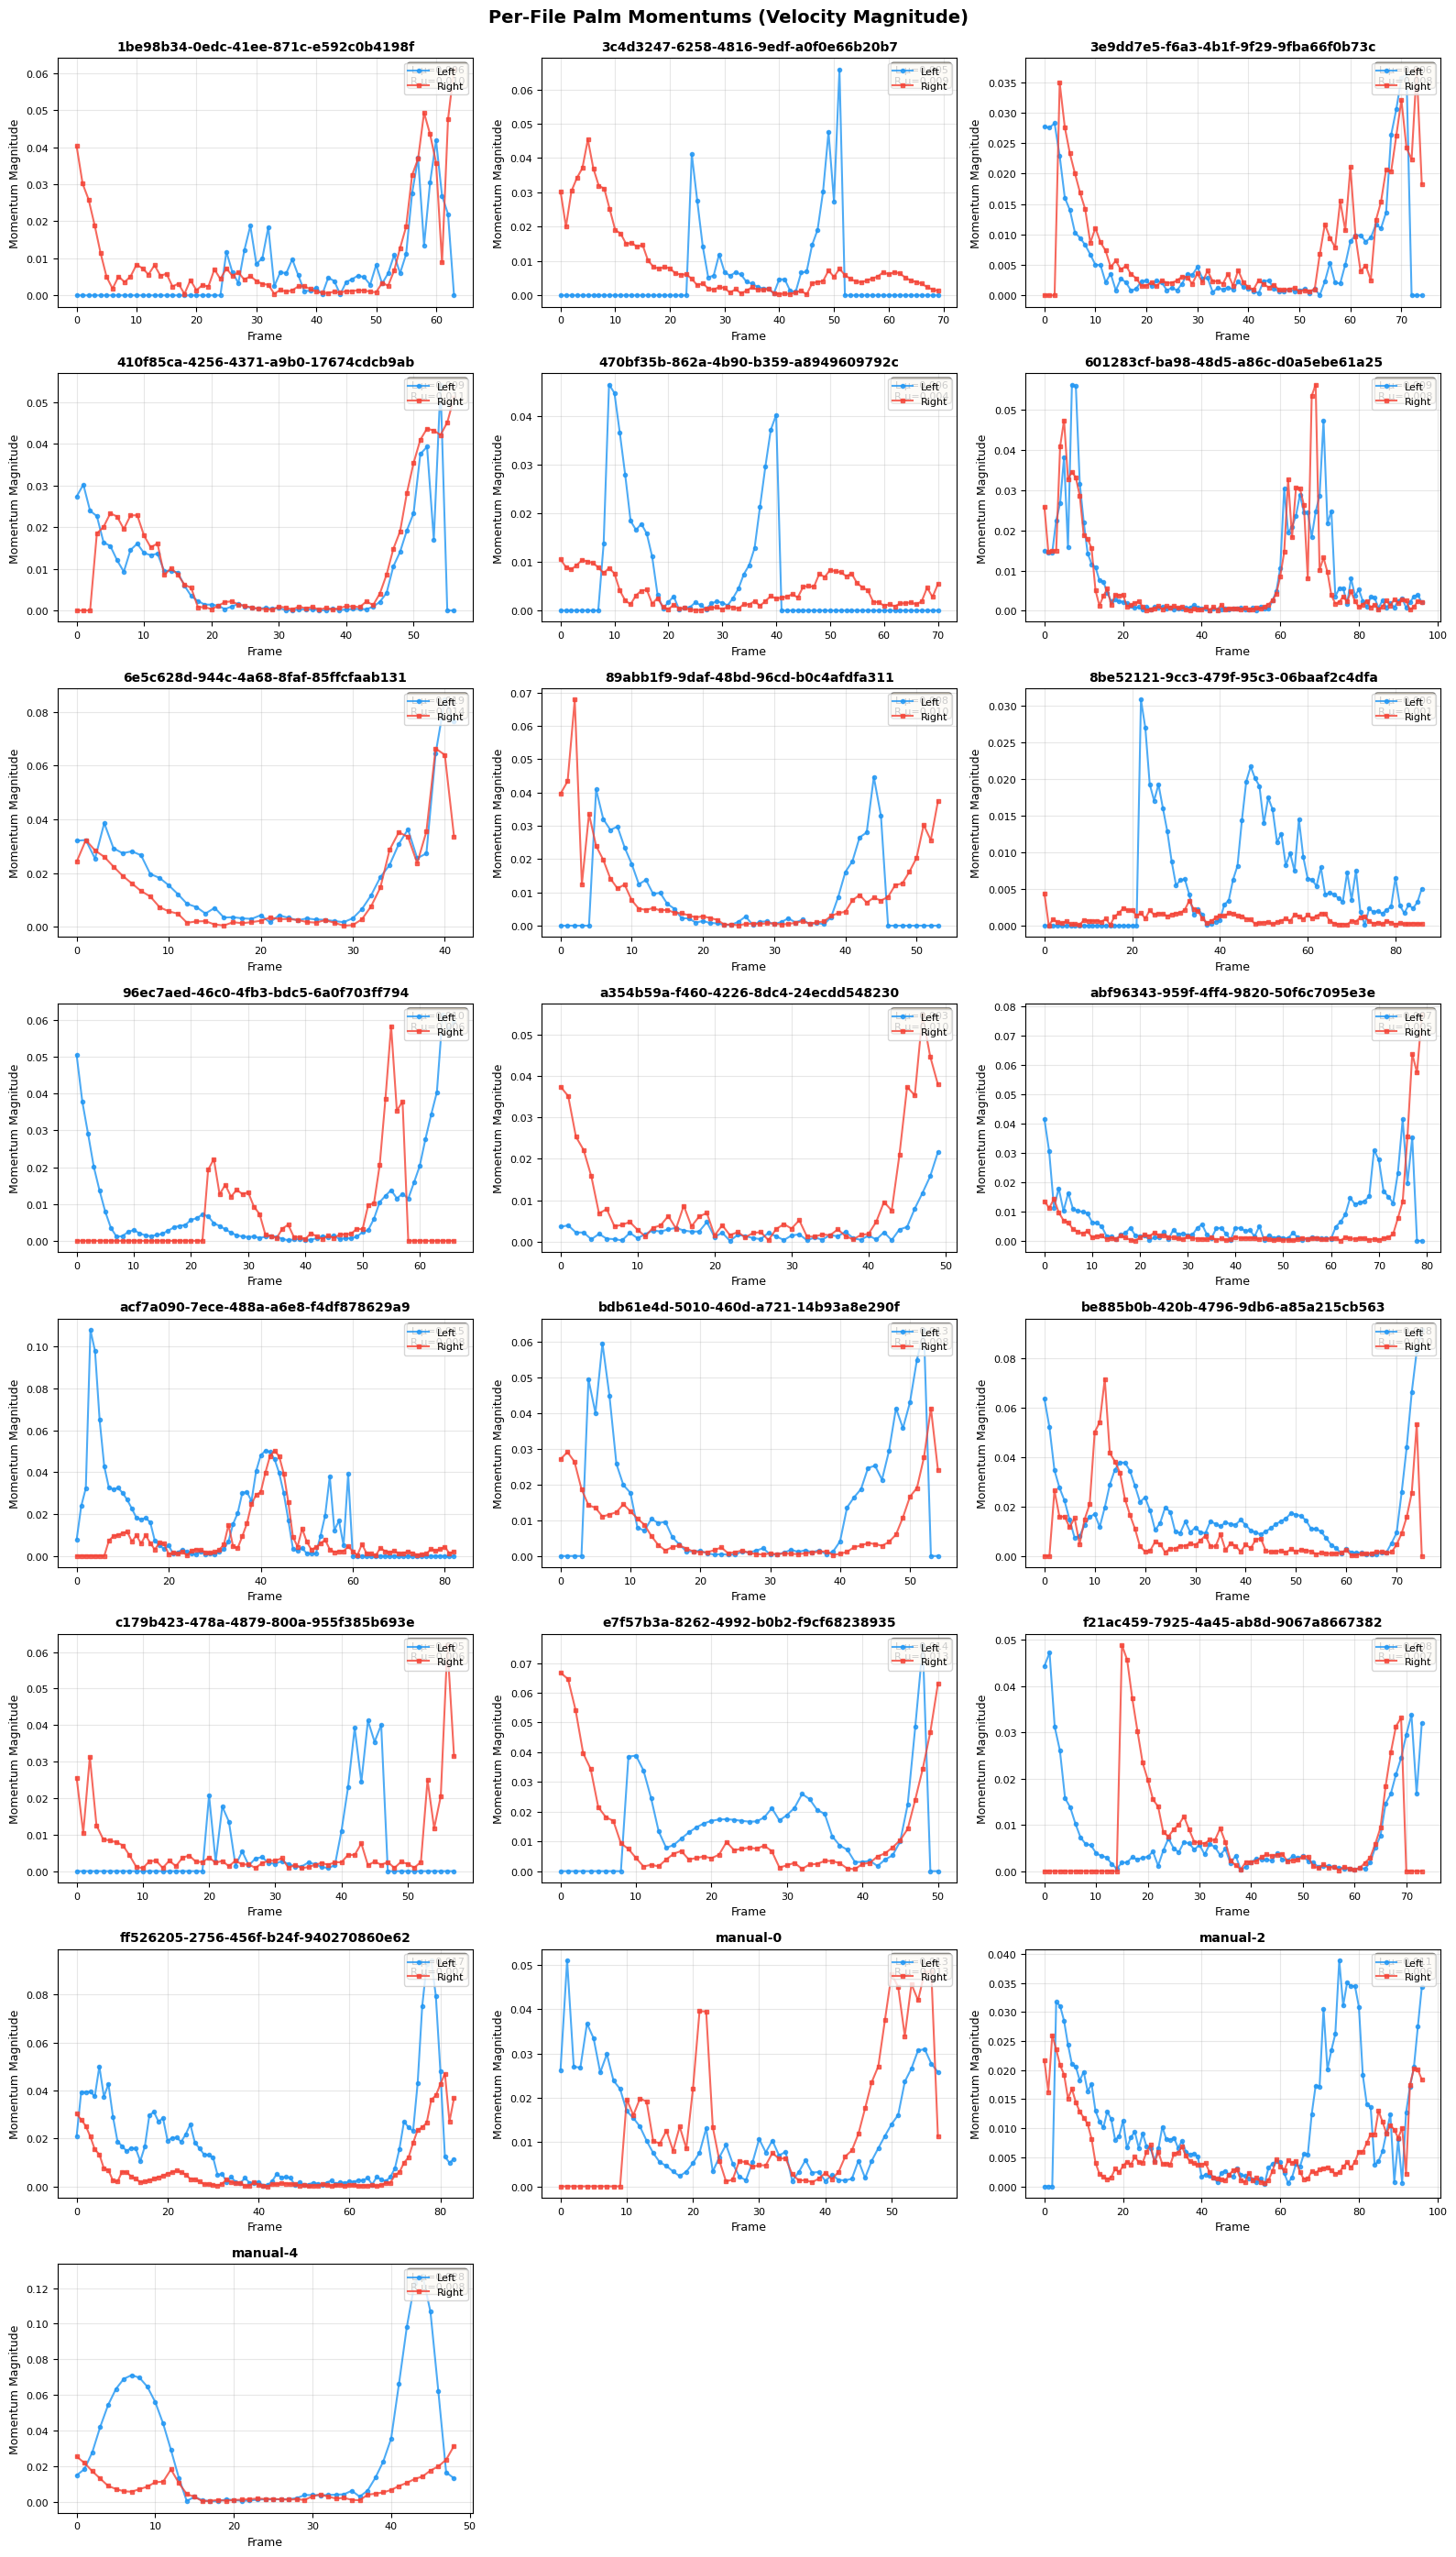


=== Momentum Analysis Summary ===
                                file  left_momentum_count  right_momentum_count  left_mean  right_mean  left_max  right_max
1be98b34-0edc-41ee-871c-e592c0b4198f                   64                    64   0.006227    0.009923  0.041882   0.061040
3c4d3247-6258-4816-9edf-a0f0e66b20b7                   70                    70   0.005368    0.008987  0.065844   0.045406
3e9dd7e5-f6a3-4b1f-9f29-9fba66f0b73c                   75                    75   0.006387    0.007993  0.036408   0.037109
410f85ca-4256-4371-a9b0-17674cdcb9ab                   57                    57   0.008865    0.011197  0.054283   0.051103
470bf35b-862a-4b90-b359-a8949609792c                   71                    71   0.006100    0.003732  0.046511   0.010516
601283cf-ba98-48d5-a86c-d0a5ebe61a25                   97                    97   0.008524    0.007884  0.056262   0.056349
6e5c628d-944c-4a68-8faf-85ffcfaab131                   42                    42   0.018610    0.0

In [ ]:
from Validators.keypoint_validator import CubicSplineKeyPointInterpolator
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Path to the temporal cropping level directory
corpus_path = Path(r'C:\Users\Oscar Strong\Documents\GitHub\BSL-keypoint-processing\Testing_post_error_ditection_pipeline\Corpus_level_2b')

# Get all JSON files
json_files = sorted(corpus_path.glob('*.json'))

# Create per-file momentum plots
n_files = len(json_files)
n_cols = 3
n_rows = int(np.ceil(n_files / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Per-File Palm Momentums (Velocity Magnitude)', fontsize=14, fontweight='bold', y=0.995)
axes_flat = axes.flatten() if n_files > 1 else [axes]

results_momentum = []

for idx, json_file in enumerate(json_files):
    try:
        # Create interpolator and get momentums
        interpolator = CubicSplineKeyPointInterpolator(str(json_file))
        momentums = interpolator.getEstimatedMomentums()
        
        file_label = json_file.stem
        
        # Extract momentum magnitudes
        left_mags = [m['left']['magnitude'] for m in momentums if m['left']['magnitude'] is not None]
        right_mags = [m['right']['magnitude'] for m in momentums if m['right']['magnitude'] is not None]
        
        results_momentum.append({
            'file': file_label,
            'left_momentum_count': len(left_mags),
            'right_momentum_count': len(right_mags),
            'left_mean': np.mean(left_mags) if left_mags else None,
            'right_mean': np.mean(right_mags) if right_mags else None,
            'left_max': np.max(left_mags) if left_mags else None,
            'right_max': np.max(right_mags) if right_mags else None,
        })
        
        # Plot
        ax = axes_flat[idx]
        
        # Plot left hand momentum
        if left_mags:
            left_frames = [i for i in range(len(momentums)) if momentums[i]['left']['magnitude'] is not None]
            ax.plot(left_frames, left_mags, color='#2196F3', linewidth=1.5, alpha=0.8, label='Left', marker='o', markersize=3)
        
        # Plot right hand momentum
        if right_mags:
            right_frames = [i for i in range(len(momentums)) if momentums[i]['right']['magnitude'] is not None]
            ax.plot(right_frames, right_mags, color='#F44336', linewidth=1.5, alpha=0.8, label='Right', marker='s', markersize=3)
        
        ax.set_title(f'{file_label}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Frame', fontsize=9)
        ax.set_ylabel('Momentum Magnitude', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=8, loc='upper right')
        
        # Add statistics
        left_mean = np.mean(left_mags) if left_mags else 0
        right_mean = np.mean(right_mags) if right_mags else 0
        stats_text = f'L μ={left_mean:.3f}\nR μ={right_mean:.3f}'
        ax.text(0.98, 0.97, stats_text, 
               transform=ax.transAxes, fontsize=8, verticalalignment='top',
               horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
    except Exception as e:
        print(f"Error processing {json_file.name}: {e}")
        ax = axes_flat[idx]
        ax.text(0.5, 0.5, f'Error: {str(e)[:30]}', ha='center', va='center', fontsize=9)
        ax.set_title(json_file.stem, fontsize=10, color='red')

# Hide unused subplots
for idx in range(n_files, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Momentum Analysis Summary ===")
if results_momentum:
    import pandas as pd
    df = pd.DataFrame(results_momentum)
    print(df.to_string(index=False))
    print(f"\nCorpus-wide Momentum Statistics:")
    print(f"  Mean LEFT momentum (all files): {df['left_mean'].mean():.4f}")
    print(f"  Mean RIGHT momentum (all files): {df['right_mean'].mean():.4f}")
    print(f"  Max LEFT momentum (overall): {df['left_max'].max():.4f}")
    print(f"  Max RIGHT momentum (overall): {df['right_max'].max():.4f}")

## Per-File closes keypoint diances 

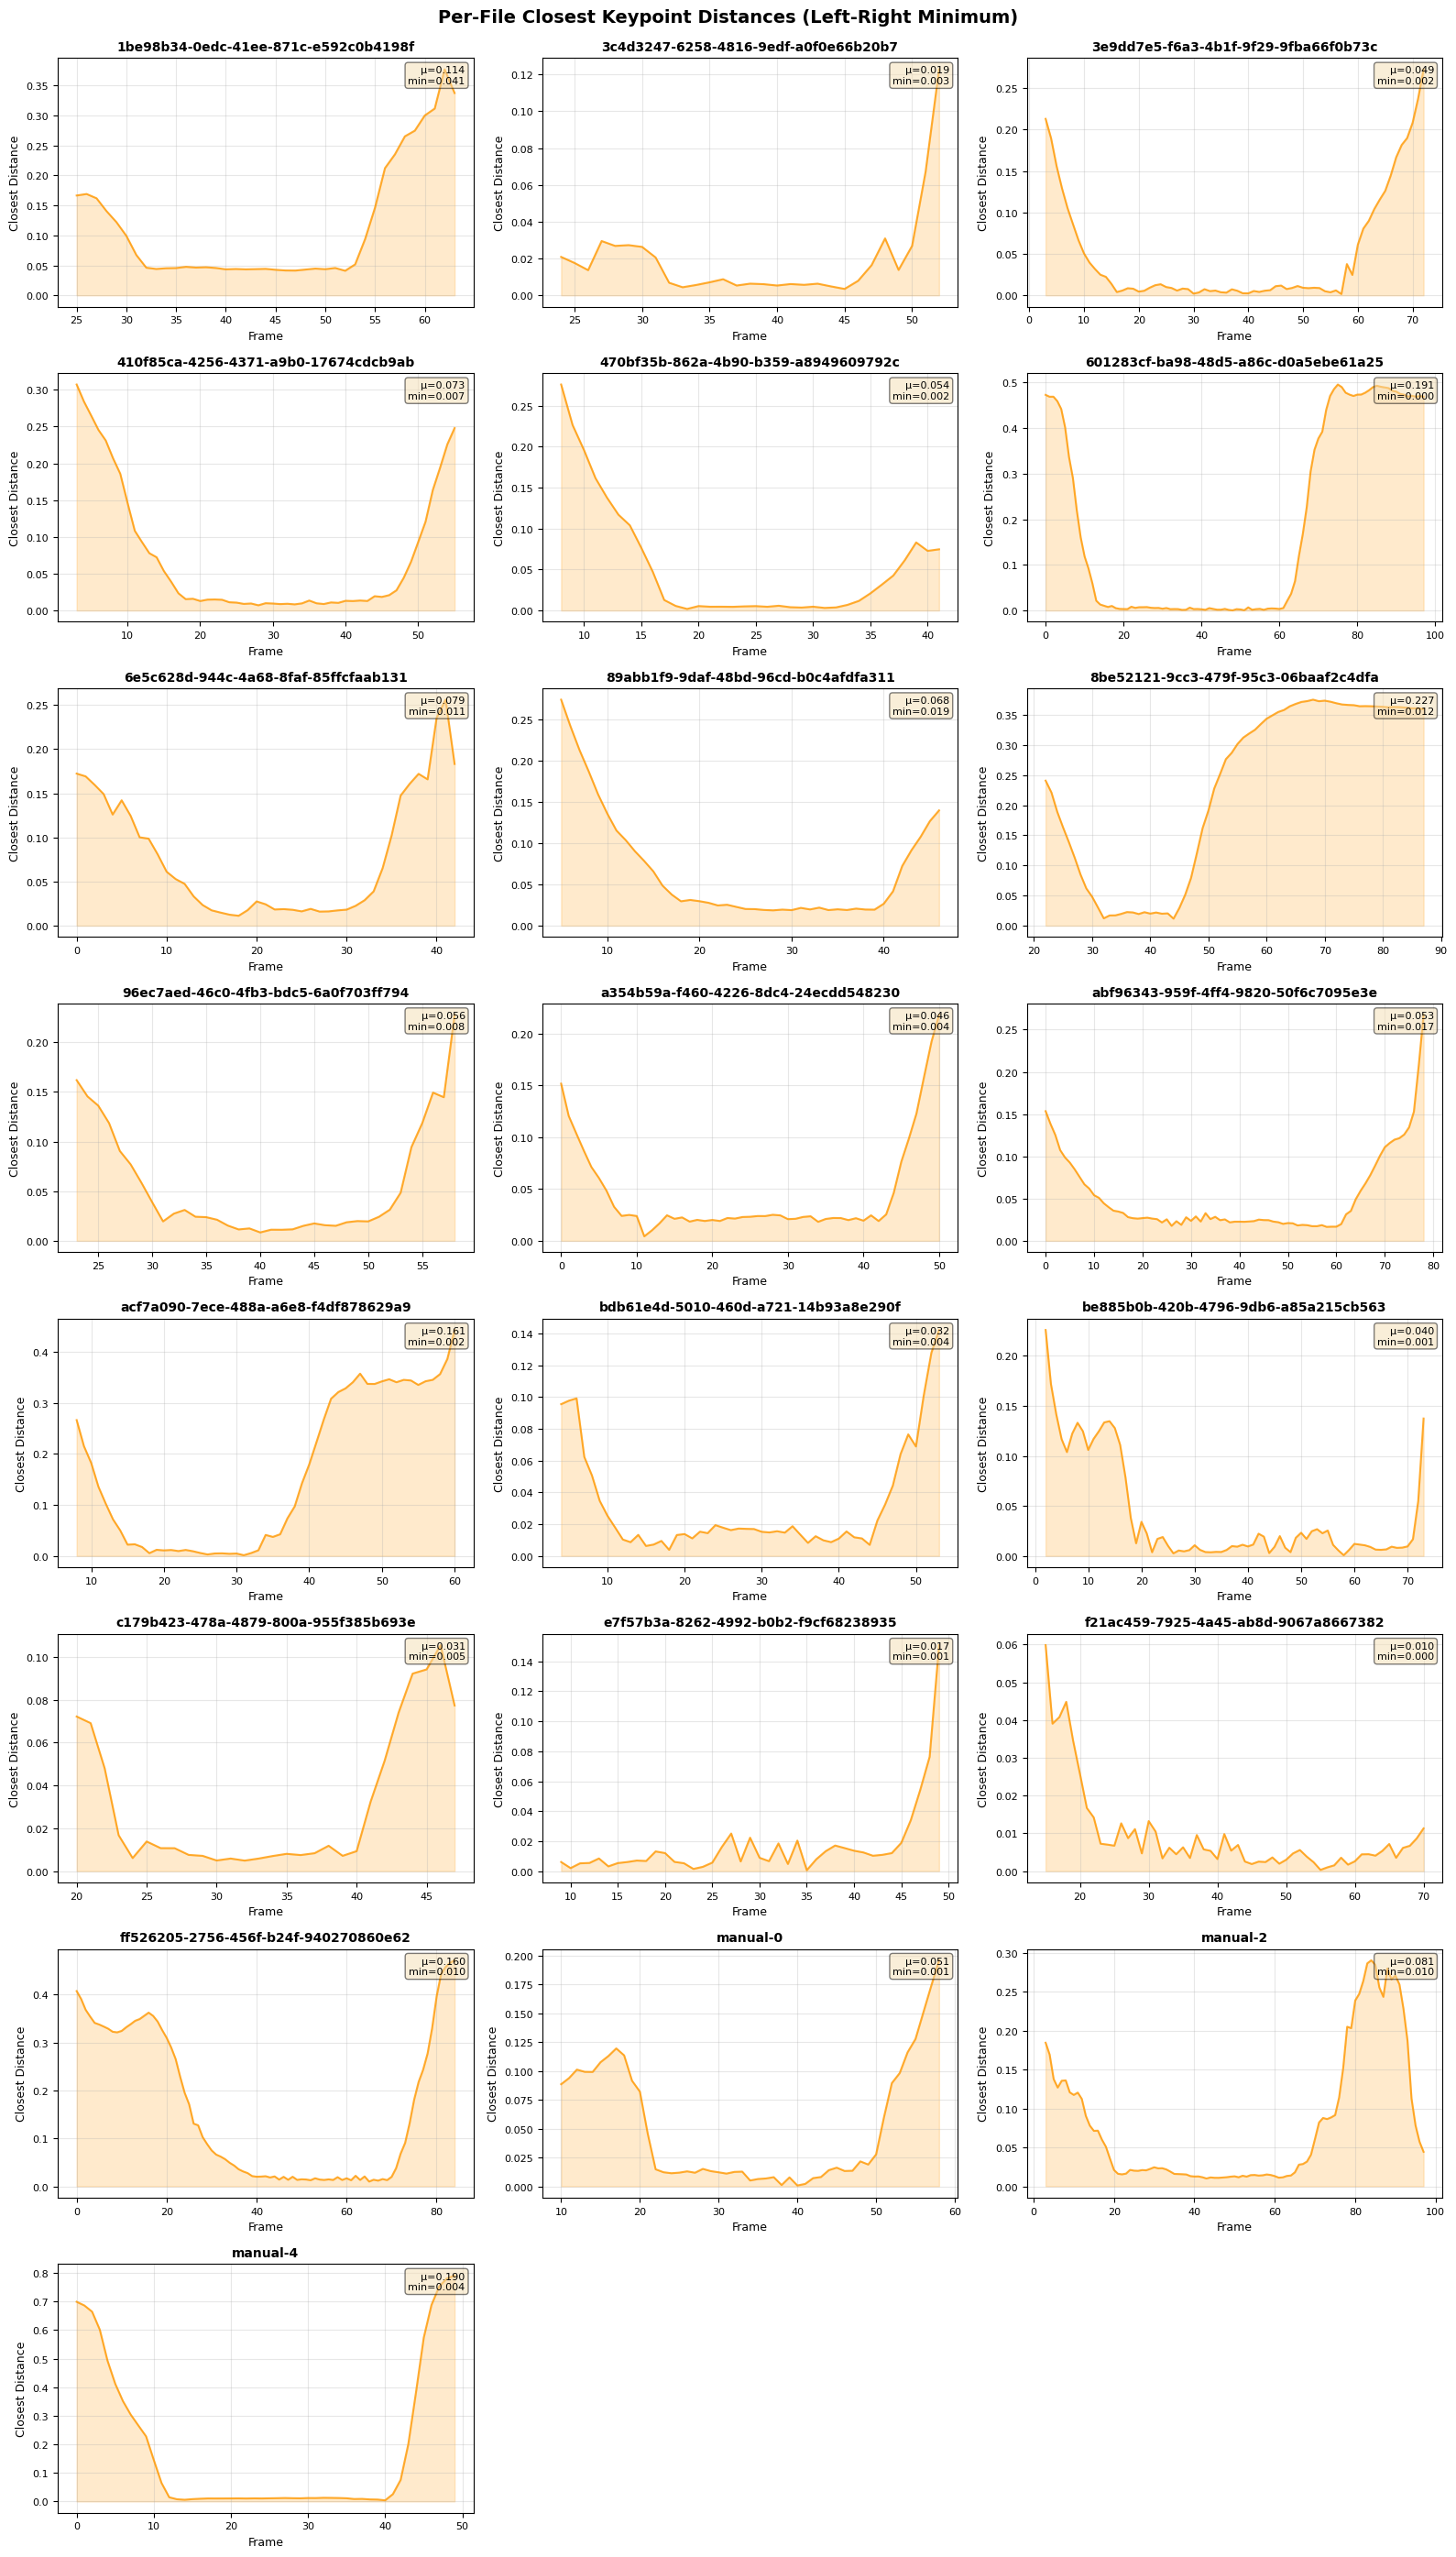


=== Closest Keypoint Distances Analysis Summary ===
                                file  distance_count  mean_distance  max_distance  min_distance
1be98b34-0edc-41ee-871c-e592c0b4198f              39       0.114451      0.377117      0.041020
3c4d3247-6258-4816-9edf-a0f0e66b20b7              29       0.019010      0.122804      0.003498
3e9dd7e5-f6a3-4b1f-9f29-9fba66f0b73c              70       0.049328      0.272571      0.001639
410f85ca-4256-4371-a9b0-17674cdcb9ab              53       0.073246      0.307231      0.007135
470bf35b-862a-4b90-b359-a8949609792c              34       0.053797      0.276020      0.001920
601283cf-ba98-48d5-a86c-d0a5ebe61a25              98       0.190891      0.495630      0.000382
6e5c628d-944c-4a68-8faf-85ffcfaab131              43       0.079114      0.256078      0.011226
89abb1f9-9daf-48bd-96cd-b0c4afdfa311              42       0.067617      0.273459      0.018581
8be52121-9cc3-479f-95c3-06baaf2c4dfa              66       0.227269      0.375138  

In [ ]:
from Validators.keypoint_validator import CubicSplineKeyPointInterpolator
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Path to the temporal cropping level directory
corpus_path = Path(r'C:\Users\Oscar Strong\Documents\GitHub\BSL-keypoint-processing\Testing_post_error_ditection_pipeline\Corpus_level_2b')

# Get all JSON files
json_files = sorted(corpus_path.glob('*.json'))

# Create per-file closest keypoint distance plots
n_files = len(json_files)
n_cols = 3
n_rows = int(np.ceil(n_files / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Per-File Closest Keypoint Distances (Left-Right Minimum)', fontsize=14, fontweight='bold', y=0.995)
axes_flat = axes.flatten() if n_files > 1 else [axes]

results_closest = []

for idx, json_file in enumerate(json_files):
    try:
        # Create interpolator and get closest keypoint distances
        interpolator = CubicSplineKeyPointInterpolator(str(json_file))
        closest_distances = interpolator.find_closest_distances()
        
        file_label = json_file.stem
        
        # Filter out None values
        valid_distances = [d for d in closest_distances if d is not None]
        
        results_closest.append({
            'file': file_label,
            'distance_count': len(valid_distances),
            'mean_distance': np.mean(valid_distances) if valid_distances else None,
            'max_distance': np.max(valid_distances) if valid_distances else None,
            'min_distance': np.min(valid_distances) if valid_distances else None,
        })
        
        # Plot
        ax = axes_flat[idx]
        frame_indices = [i for i, d in enumerate(closest_distances) if d is not None]
        distance_values = [d for d in closest_distances if d is not None]
        
        if distance_values:
            ax.plot(frame_indices, distance_values, color='#FF9800', linewidth=1.5, alpha=0.8)
            ax.fill_between(frame_indices, distance_values, alpha=0.2, color='#FF9800')
            
            # Add statistics text
            mean_d = np.mean(distance_values)
            min_d = np.min(distance_values)
            ax.text(0.98, 0.97, f'μ={mean_d:.3f}\nmin={min_d:.3f}', 
                   transform=ax.transAxes, fontsize=8, verticalalignment='top', 
                   horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_title(f'{file_label}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Frame', fontsize=9)
        ax.set_ylabel('Closest Distance', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)
        
    except Exception as e:
        print(f"Error processing {json_file.name}: {e}")
        ax = axes_flat[idx]
        ax.text(0.5, 0.5, f'Error: {str(e)[:30]}', ha='center', va='center', fontsize=9)
        ax.set_title(json_file.stem, fontsize=10, color='red')

# Hide unused subplots
for idx in range(n_files, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Closest Keypoint Distances Analysis Summary ===")
if results_closest:
    import pandas as pd
    df = pd.DataFrame(results_closest)
    print(df.to_string(index=False))
    print(f"\nCorpus-wide Closest Distance Statistics:")
    print(f"  Mean closest distance (all files): {df['mean_distance'].mean():.4f}")
    print(f"  Max closest distance (overall): {df['max_distance'].max():.4f}")
    print(f"  Min closest distance (overall): {df['min_distance'].min():.4f}")
    print(f"  Average frames analyzed per file: {df['distance_count'].mean():.1f}")

In [ ]:
def analyze_keypoint_file(json_path):
    """
    Analyze a single keypoint JSON file and generate visualizations for:
    - Palm Distances (Interpolated)
    - Palm Momentums (Velocity Magnitude)
    - Closest Keypoint Distances
    
    Parameters:
    -----------
    json_path : str
        Path to the JSON file to analyze
    """
    from Validators.keypoint_validator import CubicSplineKeyPointInterpolator
    import matplotlib.pyplot as plt
    import numpy as np
    from pathlib import Path
    
    try:
        # Create interpolator
        interpolator = CubicSplineKeyPointInterpolator(str(json_path))
        file_label = Path(json_path).stem
        
        # Get data
        palm_distances = interpolator.findPalmDistances()
        momentums = interpolator.getEstimatedMomentums()
        closest_distances = interpolator.find_closest_distances()        
        # Extract momentum magnitudes
        left_mags = [m['left']['magnitude'] for m in momentums if m['left']['magnitude'] is not None]
        right_mags = [m['right']['magnitude'] for m in momentums if m['right']['magnitude'] is not None]
        
        # Create figure with 3 subplots
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle(f'Keypoint Analysis: {file_label}', fontsize=14, fontweight='bold')
        
        # Plot 1: Palm Distances (Interpolated)
        ax = axes[0]
        frame_indices = [i for i, d in enumerate(palm_distances) if d is not None]
        distance_values = [d for d in palm_distances if d is not None]
        
        if distance_values:
            ax.plot(frame_indices, distance_values, color='#2196F3', linewidth=2, alpha=0.8)
            ax.fill_between(frame_indices, distance_values, alpha=0.2, color='#2196F3')
            mean_d = np.mean(distance_values)
            max_d = np.max(distance_values)
            ax.text(0.98, 0.97, f'μ={mean_d:.3f}\nmax={max_d:.3f}', 
                   transform=ax.transAxes, fontsize=9, verticalalignment='top', 
                   horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
        
        ax.set_title('Palm Distances (Interpolated)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Frame', fontsize=10)
        ax.set_ylabel('Distance', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Plot 2: Palm Momentums (Velocity Magnitude)
        ax = axes[1]
        
        if left_mags:
            left_frames = [i for i in range(len(momentums)) if momentums[i]['left']['magnitude'] is not None]
            ax.plot(left_frames, left_mags, color='#2196F3', linewidth=2, alpha=0.8, label='Left', marker='o', markersize=3)
        
        if right_mags:
            right_frames = [i for i in range(len(momentums)) if momentums[i]['right']['magnitude'] is not None]
            ax.plot(right_frames, right_mags, color='#F44336', linewidth=2, alpha=0.8, label='Right', marker='s', markersize=3)
        
        left_mean = np.mean(left_mags) if left_mags else 0
        right_mean = np.mean(right_mags) if right_mags else 0
        ax.text(0.98, 0.97, f'L μ={left_mean:.3f}\nR μ={right_mean:.3f}', 
               transform=ax.transAxes, fontsize=9, verticalalignment='top',
               horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
        
        ax.set_title('Palm Momentums (Velocity Magnitude)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Frame', fontsize=10)
        ax.set_ylabel('Momentum Magnitude', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc='upper right')
        
        # Plot 3: Closest Keypoint Distances
        ax = axes[2]
        frame_indices = [i for i, d in enumerate(closest_distances) if d is not None]
        distance_values = [d for d in closest_distances if d is not None]
        
        if distance_values:
            ax.plot(frame_indices, distance_values, color='#FF9800', linewidth=2, alpha=0.8)
            ax.fill_between(frame_indices, distance_values, alpha=0.2, color='#FF9800')
            mean_d = np.mean(distance_values)
            min_d = np.min(distance_values)
            ax.text(0.98, 0.97, f'μ={mean_d:.3f}\nmin={min_d:.3f}', 
                   transform=ax.transAxes, fontsize=9, verticalalignment='top', 
                   horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.7))
        
        ax.set_title('Closest Keypoint Distances', fontsize=11, fontweight='bold')
        ax.set_xlabel('Frame', fontsize=10)
        ax.set_ylabel('Closest Distance', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"\n=== Analysis Summary for {file_label} ===")
        print(f"Palm Distances: {len([d for d in palm_distances if d is not None])} frames")
        print(f"  Mean: {np.mean([d for d in palm_distances if d is not None]):.4f}")
        print(f"  Max: {np.max([d for d in palm_distances if d is not None]):.4f}")
        print(f"  Min: {np.min([d for d in palm_distances if d is not None]):.4f}")
        
        print(f"\nPalm Momentums:")
        print(f"  LEFT - Count: {len(left_mags)}, Mean: {np.mean(left_mags):.4f}, Max: {np.max(left_mags):.4f}")
        print(f"  RIGHT - Count: {len(right_mags)}, Mean: {np.mean(right_mags):.4f}, Max: {np.max(right_mags):.4f}")
        
        print(f"\nClosest Keypoint Distances: {len([d for d in closest_distances if d is not None])} frames")
        valid_closest = [d for d in closest_distances if d is not None]
        if valid_closest:
            print(f"  Mean: {np.mean(valid_closest):.4f}")
            print(f"  Max: {np.max(valid_closest):.4f}")
            print(f"  Min: {np.min(valid_closest):.4f}")
        
    except Exception as e:
        print(f"Error analyzing {json_path}: {e}")
        import traceback
        traceback.print_exc()


\3c4d3247-6258-4816-9edf-a0f0e66b20b7.json


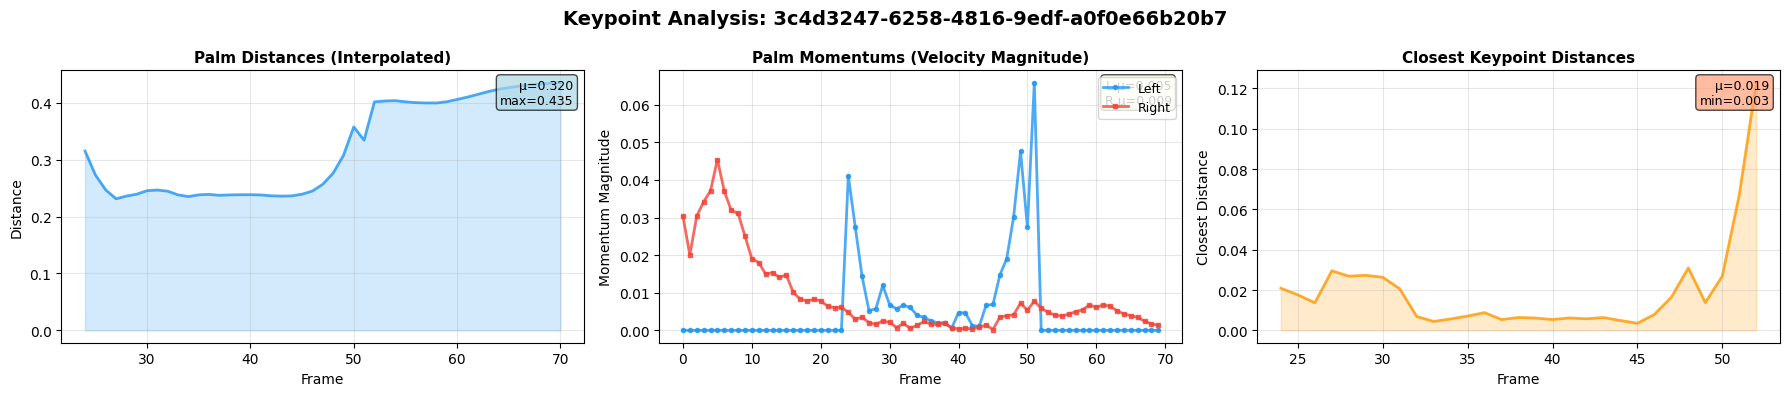


=== Analysis Summary for 3c4d3247-6258-4816-9edf-a0f0e66b20b7 ===
Palm Distances: 47 frames
  Mean: 0.3196
  Max: 0.4352
  Min: 0.2312

Palm Momentums:
  LEFT - Count: 70, Mean: 0.0054, Max: 0.0658
  RIGHT - Count: 70, Mean: 0.0090, Max: 0.0454

Closest Keypoint Distances: 29 frames
  Mean: 0.0190
  Max: 0.1228
  Min: 0.0035
\8be52121-9cc3-479f-95c3-06baaf2c4dfa.json


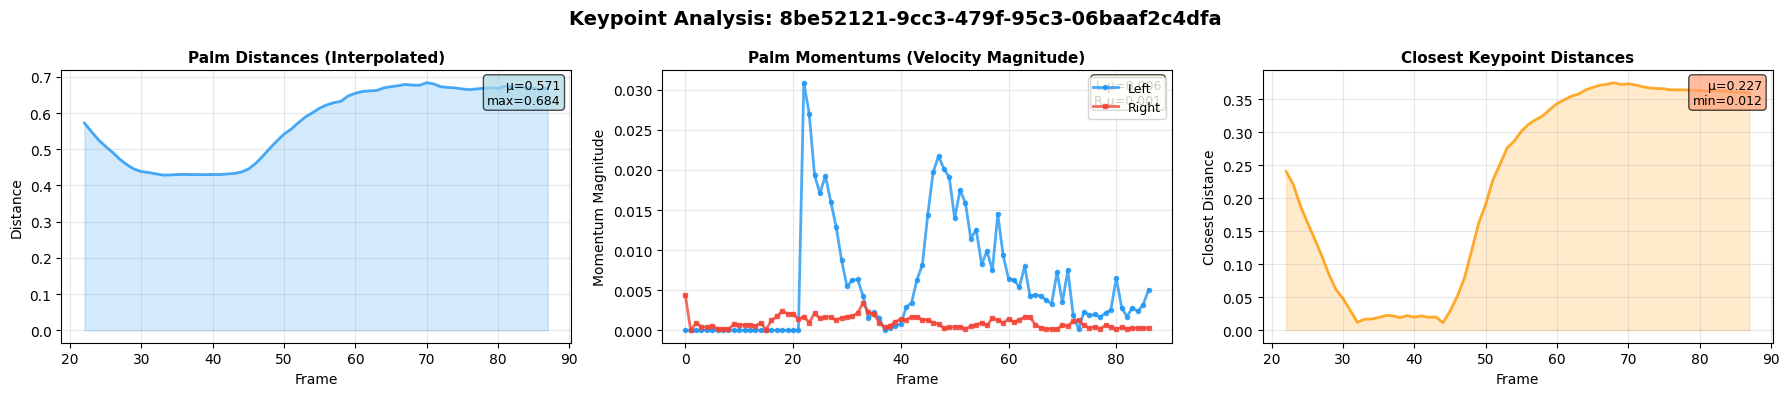


=== Analysis Summary for 8be52121-9cc3-479f-95c3-06baaf2c4dfa ===
Palm Distances: 66 frames
  Mean: 0.5709
  Max: 0.6838
  Min: 0.4288

Palm Momentums:
  LEFT - Count: 87, Mean: 0.0060, Max: 0.0309
  RIGHT - Count: 87, Mean: 0.0010, Max: 0.0044

Closest Keypoint Distances: 66 frames
  Mean: 0.2273
  Max: 0.3751
  Min: 0.0116
\acf7a090-7ece-488a-a6e8-f4df878629a9.json


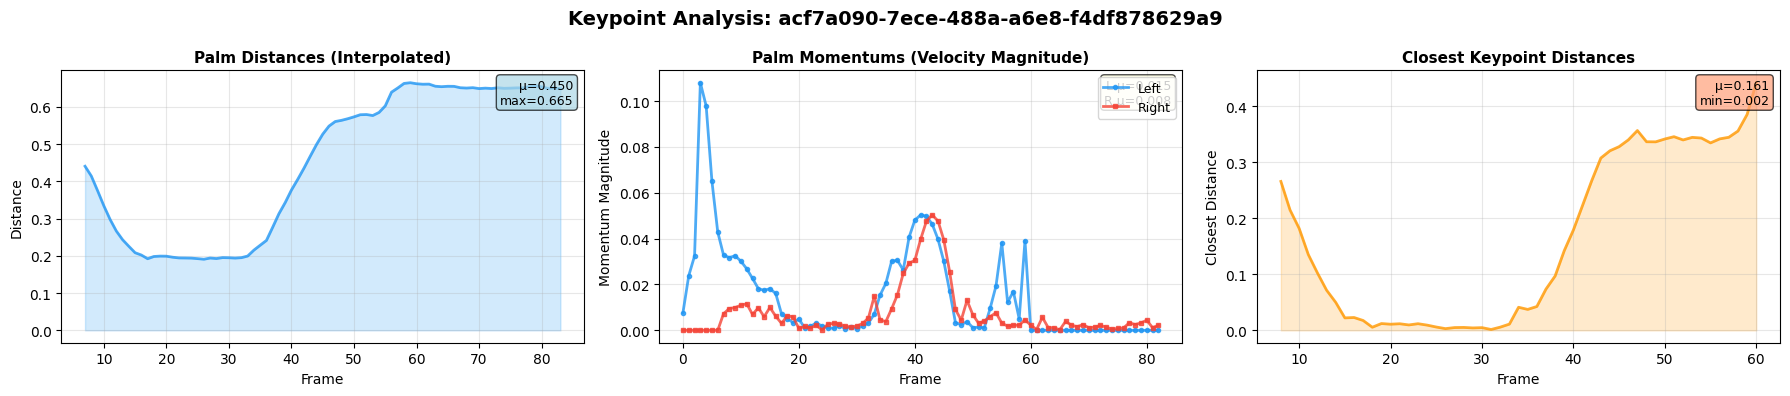


=== Analysis Summary for acf7a090-7ece-488a-a6e8-f4df878629a9 ===
Palm Distances: 77 frames
  Mean: 0.4504
  Max: 0.6649
  Min: 0.1909

Palm Momentums:
  LEFT - Count: 83, Mean: 0.0153, Max: 0.1080
  RIGHT - Count: 83, Mean: 0.0076, Max: 0.0504

Closest Keypoint Distances: 53 frames
  Mean: 0.1615
  Max: 0.4424
  Min: 0.0015
\e7f57b3a-8262-4992-b0b2-f9cf68238935.json


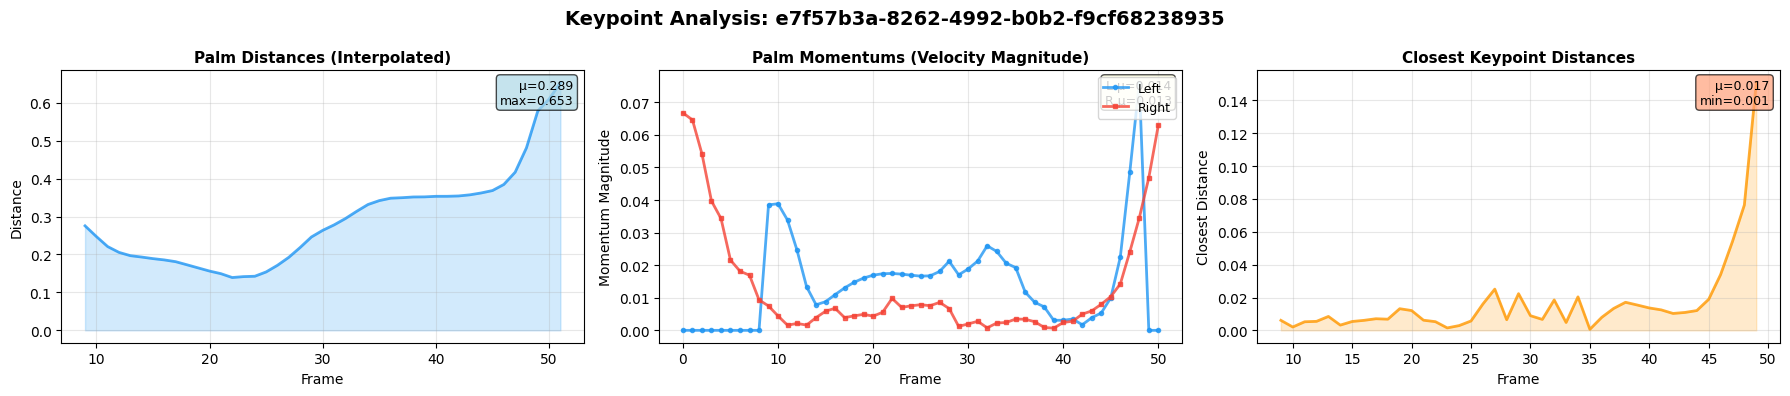


=== Analysis Summary for e7f57b3a-8262-4992-b0b2-f9cf68238935 ===
Palm Distances: 43 frames
  Mean: 0.2893
  Max: 0.6527
  Min: 0.1392

Palm Momentums:
  LEFT - Count: 51, Mean: 0.0143, Max: 0.0760
  RIGHT - Count: 51, Mean: 0.0133, Max: 0.0667

Closest Keypoint Distances: 41 frames
  Mean: 0.0166
  Max: 0.1508
  Min: 0.0006


In [13]:
base = r"C:\Users\Oscar Strong\Documents\GitHub\BSL-keypoint-processing\Validated_interpolated_SubCorpus_Temporal_Cropping_level1"

a = r"\3c4d3247-6258-4816-9edf-a0f0e66b20b7.json"

b = r"\8be52121-9cc3-479f-95c3-06baaf2c4dfa.json"
 
c = r"\acf7a090-7ece-488a-a6e8-f4df878629a9.json"
 
d = r"\e7f57b3a-8262-4992-b0b2-f9cf68238935.json"

print(a)
analyze_keypoint_file(base+a)


print(b)
analyze_keypoint_file(base+b)


print(c)
analyze_keypoint_file(base+c)


print(d)
analyze_keypoint_file(base+d)
